LONG SHORT TERM MEMORY

In [1]:
# Dependencies managed via requirements.txt
# pip install -r requirements.txt

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

# Safe device detection (CPU / GPU compatibility)
gpus = tf.config.list_physical_devices("GPU")
if gpus:
    print("GPU available:", gpus)
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
    except RuntimeError:
        pass
else:
    print("GPU not available. Using CPU.")

GPU not available. Using CPU.


In [3]:
from pathlib import Path

DATASET_PATH = Path("household_power_consumption.csv")
if not DATASET_PATH.exists() and (Path("FRANCE_DATASET") / "household_power_consumption.csv").exists():
    DATASET_PATH = Path("FRANCE_DATASET") / "household_power_consumption.csv"

file_path = DATASET_PATH

df = pd.read_csv(
    file_path,
    sep=';',
    header=None
)

print(df.shape)
df.head()

C:\Users\Dell\AppData\Local\Temp\ipykernel_8912\1519563691.py:9: DtypeWarning: Columns (0: 2, 1: 3, 2: 4, 3: 5, 4: 6, 5: 7, 6: 8) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(


(2075260, 9)


,0,1,2,3,4,5,6,7,8
0,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
1,16/12/2006,17:24:00,4.216,0.418,234.840,18.400,0.000,1.000,17.000
2,16/12/2006,17:25:00,5.360,0.436,233.630,23.000,0.000,1.000,16.000
3,16/12/2006,17:26:00,5.374,0.498,233.290,23.000,0.000,2.000,17.000
4,16/12/2006,17:27:00,5.388,0.502,233.740,23.000,0.000,1.000,17.000


In [4]:
df.columns = [
    'Date',
    'Time',
    'Global_active_power',
    'Global_reactive_power',
    'Voltage',
    'Global_intensity',
    'Sub_metering_1',
    'Sub_metering_2',
    'Sub_metering_3'
]

df.head()

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
1,16/12/2006,17:24:00,4.216,0.418,234.840,18.400,0.000,1.000,17.000
2,16/12/2006,17:25:00,5.360,0.436,233.630,23.000,0.000,1.000,16.000
3,16/12/2006,17:26:00,5.374,0.498,233.290,23.000,0.000,2.000,17.000
4,16/12/2006,17:27:00,5.388,0.502,233.740,23.000,0.000,1.000,17.000


In [5]:
# Convert numerical columns
numeric_columns = [
    'Global_active_power',
    'Global_reactive_power',
    'Voltage',
    'Global_intensity',
    'Sub_metering_1',
    'Sub_metering_2',
    'Sub_metering_3'
]

for col in numeric_columns:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Remove missing values
df = df.dropna()

# Convert date and time
df['Datetime'] = pd.to_datetime(
    df['Date'] + ' ' + df['Time'],
    dayfirst=True,
    errors='coerce'
)

df = df.dropna(subset=['Datetime'])

# Sort by time
df = df.sort_values('Datetime').reset_index(drop=True)

print("Rows after cleaning:", len(df))

Rows after cleaning: 2049280


In [6]:
df = df.iloc[:100000].copy()

print("Number of records:", len(df))

Number of records: 100000


In [7]:
df = df.iloc[:50000].copy()

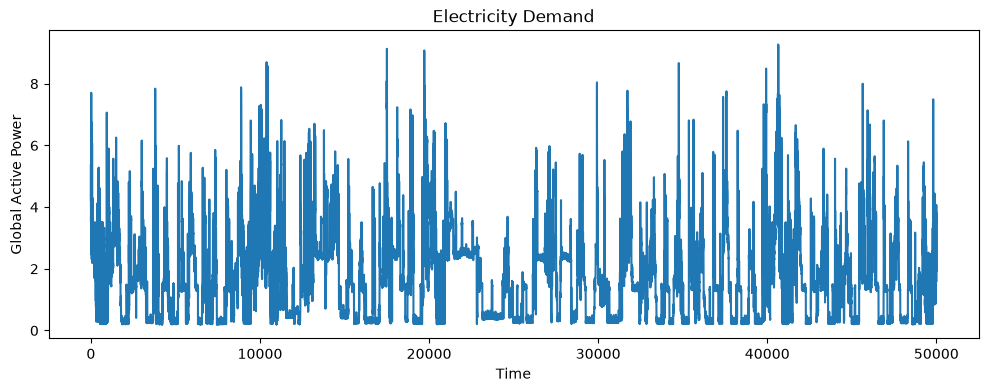

In [8]:
plt.figure(figsize=(12, 4))

plt.plot(df['Global_active_power'])

plt.xlabel('Time')
plt.ylabel('Global Active Power')

plt.title('Electricity Demand')

plt.show()

In [9]:
energy = df[['Global_active_power']].values

scaler = MinMaxScaler()

energy_scaled = scaler.fit_transform(energy)

print(energy_scaled.shape)

(50000, 1)


In [10]:
time_steps = 30

X = []
y = []

for i in range(time_steps, len(energy_scaled)):
    X.append(energy_scaled[i-time_steps:i, 0])
    y.append(energy_scaled[i, 0])

X = np.array(X)
y = np.array(y)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (49970, 30)
y shape: (49970,)


In [11]:
X = X.reshape(
    X.shape[0],
    X.shape[1],
    1
)

print("Final X shape:", X.shape)

Final X shape: (49970, 30, 1)


In [12]:
train_size = int(len(X) * 0.8)

X_train = X[:train_size]
X_test = X[train_size:]

y_train = y[:train_size]
y_test = y[train_size:]

print("Training:", X_train.shape)
print("Testing:", X_test.shape)

Training: (39976, 30, 1)
Testing: (9994, 30, 1)


In [13]:
model = Sequential()

model.add(
    LSTM(
        32,
        input_shape=(X_train.shape[1], 1)
    )
)

model.add(Dropout(0.1))

model.add(Dense(16, activation='relu'))

model.add(Dense(1))

model.compile(
    optimizer='adam',
    loss='mse'
)

model.summary()

c:\Users\Dell\AppData\Local\Programs\Python\Python314\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 32)             │         4,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,897 (19.13 KB)

 Trainable params: 4,897 (19.13 KB)

 Non-trainable params: 0 (0.00 B)

In [14]:
history = model.fit(
    X_train,
    y_train,
    epochs=5,
    batch_size=128,
    validation_split=0.1,
    verbose=1
)

Epoch 1/5
282/282 ━━━━━━━━━━━━━━━━━━━━ 7s 21ms/step - loss: 0.0042 - val_loss: 0.0017
Epoch 2/5
282/282 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - loss: 0.0027 - val_loss: 0.0014
Epoch 3/5
282/282 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - loss: 0.0025 - val_loss: 0.0013
Epoch 4/5
282/282 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - loss: 0.0023 - val_loss: 0.0011
Epoch 5/5
282/282 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - loss: 0.0022 - val_loss: 0.0010


In [15]:
epochs=10

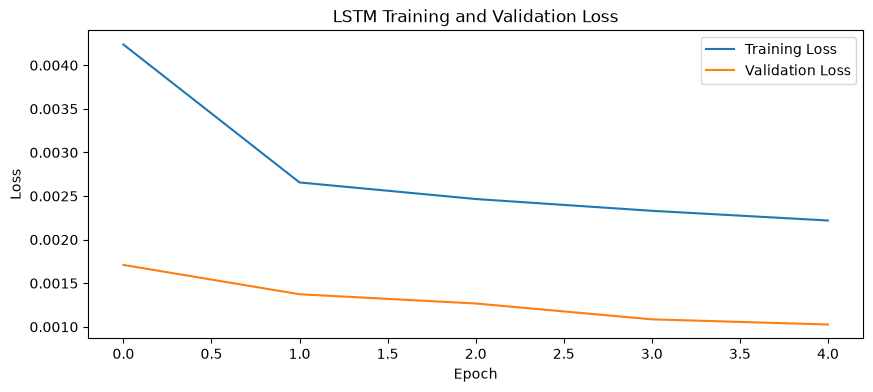

In [16]:
plt.figure(figsize=(10, 4))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.title('LSTM Training and Validation Loss')

plt.legend()

plt.show()

In [17]:
predictions = model.predict(
    X_test,
    batch_size=128
)

79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step


In [18]:
predictions_actual = scaler.inverse_transform(predictions)

y_test_actual = scaler.inverse_transform(
    y_test.reshape(-1, 1)
)

In [19]:
mae = mean_absolute_error(
    y_test_actual,
    predictions_actual
)

rmse = np.sqrt(
    mean_squared_error(
        y_test_actual,
        predictions_actual
    )
)

r2 = r2_score(
    y_test_actual,
    predictions_actual
)

print("========== LSTM PERFORMANCE ==========")
print("MAE  :", mae)
print("RMSE :", rmse)
print("R²   :", r2)

========== LSTM PERFORMANCE ==========
MAE  : 0.2576675497230015
RMSE : 0.47825513341647763
R²   : 0.8714302991935509


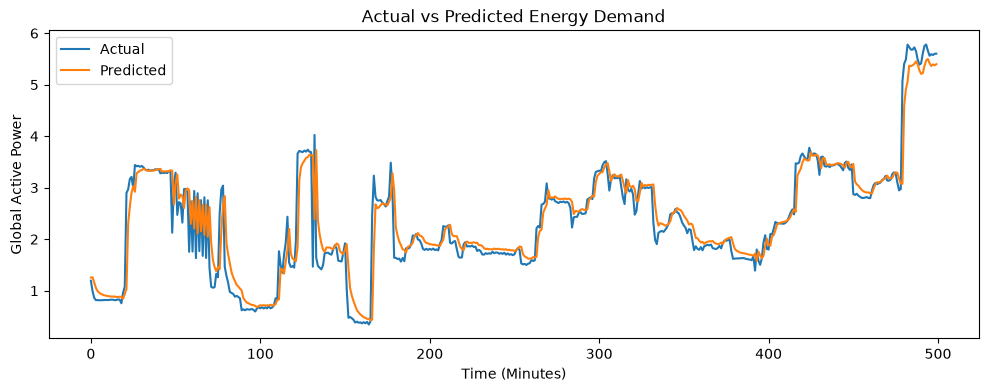

In [20]:
plt.figure(figsize=(12, 4))

plt.plot(
    y_test_actual[:500],
    label='Actual'
)

plt.plot(
    predictions_actual[:500],
    label='Predicted'
)

plt.xlabel('Time (Minutes)')
plt.ylabel('Global Active Power')

plt.title('Actual vs Predicted Energy Demand')

plt.legend()

plt.show()

In [21]:
from pathlib import Path

OUTPUT_DIR = Path("LSTM_Output")
if not OUTPUT_DIR.exists() and (Path("FRANCE_DATASET") / "LSTM_Output").exists():
    OUTPUT_DIR = Path("FRANCE_DATASET") / "LSTM_Output"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

MODEL_PATH = OUTPUT_DIR / "smart_grid_lstm_model.keras"

model.save(MODEL_PATH)

print(f"LSTM model saved successfully to {MODEL_PATH}!")

LSTM model saved successfully to LSTM_Output\smart_grid_lstm_model.keras!


In [22]:
PREDICTION_PATH = OUTPUT_DIR / "lstm_predictions.csv"

results = pd.DataFrame({
    'Actual': y_test_actual.flatten(),
    'Predicted': predictions_actual.flatten()
})

results.to_csv(
    PREDICTION_PATH,
    index=False
)

print(f"Prediction file saved successfully to {PREDICTION_PATH}!")

Prediction file saved successfully to LSTM_Output\lstm_predictions.csv!
